In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as utils
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

In [3]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# Clase Generador

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 28*28),
            nn.Tanh()
        )
    
    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28)
        return img

# Clase Discriminador

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, img):
        validity = self.model(img)
        return validity

# Instancias

In [6]:
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [7]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

In [8]:
epochs = 1

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):

        real_imgs = imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Entrenar el Discriminador
        optimizer_D.zero_grad()

        real_output = discriminator(real_imgs)
        d_loss_real = criterion(real_output, real_labels)

        z = torch.randn(batch_size, latent_dim).to(device)

        fake_imgs = generator(z)

        fake_output = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Entrenar el Generador
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, latent_dim).to(device)
        generated_imgs = generator(z)

        output = discriminator(generated_imgs)
        g_loss = criterion(output, real_labels)

        g_loss.backward()
        optimizer_G.step()

        print(f"[Epoch {epoch+1}/{epochs}] [Batch {i+1}/{len(dataloader)} \
              loss D: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

[Epoch 1/1] [Batch 1/469               loss D: 1.3809] [G loss: 0.6685]
[Epoch 1/1] [Batch 2/469               loss D: 1.2139] [G loss: 0.6574]
[Epoch 1/1] [Batch 3/469               loss D: 1.0945] [G loss: 0.6464]
[Epoch 1/1] [Batch 4/469               loss D: 0.9990] [G loss: 0.6328]
[Epoch 1/1] [Batch 5/469               loss D: 0.9417] [G loss: 0.6144]
[Epoch 1/1] [Batch 6/469               loss D: 0.9141] [G loss: 0.5906]
[Epoch 1/1] [Batch 7/469               loss D: 0.9099] [G loss: 0.5617]
[Epoch 1/1] [Batch 8/469               loss D: 0.9426] [G loss: 0.5232]
[Epoch 1/1] [Batch 9/469               loss D: 0.9858] [G loss: 0.4901]
[Epoch 1/1] [Batch 10/469               loss D: 1.0581] [G loss: 0.4494]
[Epoch 1/1] [Batch 11/469               loss D: 1.1430] [G loss: 0.4102]
[Epoch 1/1] [Batch 12/469               loss D: 1.2387] [G loss: 0.3765]
[Epoch 1/1] [Batch 13/469               loss D: 1.3292] [G loss: 0.3459]
[Epoch 1/1] [Batch 14/469               loss D: 1.4265] [G l

# Visualizas las Imágenes

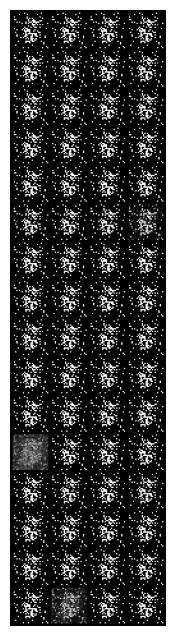

In [9]:
z = torch.randn(64, latent_dim).to(device)
generated_imgs = generator(z).detach().cpu()

grid = utils.make_grid(generated_imgs, nrow=4, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis('off')
plt.show()

# Difusión

NameError: name 'noise_img' is not defined

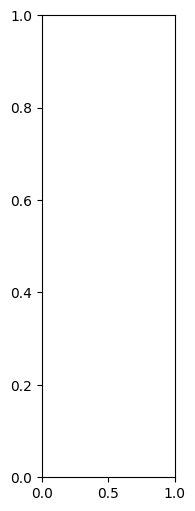

In [11]:
# Simular el proceso de entrenamiento para mostrar cómo se generan imágenes falsas a lo largo del tiempo.

sample_imgs = dataloader.dataset[0]

sample_imgs = sample_imgs[0].unsqueeze(0).to(device)

def add_noise(img, noise_level):
    noise = torch.randn_like(img)
    noise_img = (1- noise_level) * img + noise_level * noise
    return img + noise

noise_levels = [0.0, 0.25, 0.5, 0.75, 0.8, 0.1]

plt.figure(figsize=(12, 6))

for i, noise_level in enumerate(noise_levels):
    noisy_img = add_noise(sample_imgs, noise_level)
    
    plt.subplot(1, len(noise_levels), i+1)
    plt.imshow(noise_img.squeeze().cpu(), cmap='grey')
    plt.title(f"Ruido: {noise_level:.2f}")
    plt.axis('off')

plt.show()